# Delhivery: Extra Trees for Three Prediction Tasks

- ETA prediction uses an **Extra Trees Regressor**, with the **OSRM baseline** as the reference.
- Severe delay classification uses an **Extra Trees Classifier**.
- Delay propagation uses an **Extra Trees Regressor** to estimate the remaining delay at each checkpoint.
- The chronological split is preserved: the first 80% of the external training set is used for fitting, the final 20% for validation, and the external test set remains isolated.
- EDA for feature engineering uses only the external training set and does not inspect final-test targets.
- Preprocessed data remains in **sparse matrix** format; the full dataset is never converted to a dense matrix.
- Global feature importance is always available, while local SHAP explanations run when the `shap` package is installed.


## Table of Contents

1. [Environment Setup](#1-environment-setup)  
2. [Data Loading](#2-data-loading)  
3. [Data Quality Assessment](#3-data-quality-assessment)  
4. [Preprocessing](#4-preprocessing)  
5. [Aggregation: Segment → Leg → Trip](#5-aggregation-segment--leg--trip)  
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)  
7. [Feature Engineering](#7-feature-engineering)  
8. [Data Splitting and Leakage Prevention](#8-data-splitting-and-leakage-prevention)  
9. [ETA Prediction — Extra Trees Regressor](#9-eta-prediction--extra-trees-regressor)  
10. [Delay Magnitude Estimation](#10-delay-magnitude-estimation)  
11. [Severe Delay Classification — Extra Trees Classifier](#11-severe-delay-classification--extra-trees-classifier)  
12. [Delay Propagation — Extra Trees Regressor](#12-delay-propagation--extra-trees-regressor)  
13. [Explainability](#13-explainability)  
14. [Single-Shipment Prediction Example](#14-single-shipment-prediction-example)  
15. [Model Export and Conclusion](#15-model-export-and-conclusion)


## 1. Environment Setup


The notebook uses `numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib`, `seaborn`, and `joblib`. The `shap` package is optional. When available, it provides local explanations; otherwise, Extra Trees feature importance still provides global model interpretation.


In [6]:

AUTO_INSTALL_NEW_PACKAGES = False
print('No additional dependencies are installed; all models use scikit-learn.')

Không cài dependency bổ sung: chỉ dùng scikit-learn cho toàn bộ model.


In [7]:
from pathlib import Path
import os


os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')

import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_sample_weight

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    shap = None
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DELAY_THRESHOLD_MINUTES = 120
N_JOBS = 2

print('Model scope: Extra Trees for ETA, severe-delay classification, and delay propagation; OSRM is the reference baseline.')
print(f'SHAP available: {SHAP_AVAILABLE}')


Model scope: Extra Trees cho ETA, severe-delay classification và delay propagation; OSRM là baseline tham chiếu.
SHAP available: True


## 2. Data Loading


On Kaggle, the dataset is loaded directly from `/kaggle/input`. The following cell prioritizes the configured Kaggle path and falls back to local paths when necessary.


In [8]:
KAGGLE_DATA_PATH = Path(
    '/kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv'
)


def find_data_path(filename='delhivery_data.csv'):
    candidates = [
        KAGGLE_DATA_PATH,

        Path('/kaggle/input/delhivery-dataset') / filename,

        Path(filename),
        Path('data') / filename,
        Path('Delhivery-Logistics-Shipment-Data-Analysis-main') / filename,
        Path('repo2') / 'Delhivery-Logistics-Shipment-Data-Analysis-main' / filename,
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()


    matches = list(Path.cwd().glob(f'**/{filename}'))
    if matches:
        return matches[0].resolve()

    checked = '\n'.join(f'- {path}' for path in candidates)
    raise FileNotFoundError(
        f'Could not find {filename}. Checked paths:\n{checked}'
    )


DATA_PATH = find_data_path()
print(f'Data path: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')
display(raw_df.head())


Data path: /kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv
Raw shape: 144,867 rows × 24 columns


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200


### Condensed Data Dictionary

| Category | Main Fields | Purpose |
|---|---|---|
| Identifiers | `trip_uuid`, `route_schedule_uuid` | Identify each trip and route schedule |
| Route | `source_*`, `destination_*`, `route_type` | Describe geography and transport type |
| Ground truth | `od_start_time`, `od_end_time` | Calculate actual duration and final ETA |
| Plan | `osrm_time`, `osrm_distance`, `segment_osrm_*` | Provide the routing baseline for proxy delay |
| Dynamic actuals | `segment_actual_time`, `cutoff_timestamp` | Used only after a checkpoint has occurred |
| Audit fields | `actual_time`, `factor`, `segment_factor` | Excluded from start-of-trip targets and features because of leakage risk or incomplete representation of full elapsed time |


## 3. Data Quality Assessment


In [9]:
quality_summary = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_count': raw_df.isna().sum(),
    'missing_pct': raw_df.isna().mean().mul(100),
    'n_unique': raw_df.nunique(dropna=False),
}).sort_values('missing_pct', ascending=False)

display(quality_summary)

print(f'Exact duplicate rows: {raw_df.duplicated().sum():,}')
print(f'Unique trips: {raw_df["trip_uuid"].nunique():,}')
print(f'Negative segment_actual_time rows: {(raw_df["segment_actual_time"] < 0).sum():,}')
print(f'Non-positive segment_osrm_time rows: {(raw_df["segment_osrm_time"] <= 0).sum():,}')

,dtype,missing_count,missing_pct,n_unique
source_name,object,293,0.202,1499
destination_name,object,261,0.180,1469
route_schedule_uuid,object,0,0.000,1504
data,object,0,0.000,2
route_type,object,0,0.000,2
trip_uuid,object,0,0.000,14817
source_center,object,0,0.000,1508
trip_creation_time,object,0,0.000,14817
destination_center,object,0,0.000,1481
od_start_time,object,0,0.000,26369


Exact duplicate rows: 0
Unique trips: 14,817
Negative segment_actual_time rows: 21
Non-positive segment_osrm_time rows: 2,347


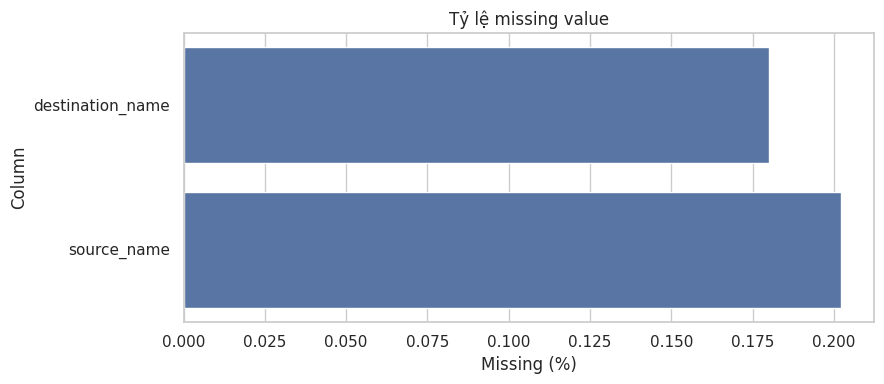

In [10]:
missing = quality_summary.query('missing_count > 0').sort_values('missing_pct')
if not missing.empty:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=missing.reset_index(), x='missing_pct', y='index', color='C0')
    plt.xlabel('Missing (%)')
    plt.ylabel('Column')
    plt.title('Missing-value percentage')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

## 4. Preprocessing


Preprocessing principles:

- Preserve the original dataframe and work on a copy.
- Parse timestamp columns with the correct datetime type.
- Fill missing location names using the most common or first valid name within the same `center`, then fall back to the center code.
- Extract `city` and `state` from location names.
- Retain anomaly flags instead of removing all logistics outliers, because long journeys and substantial delays may be genuine observations.


In [11]:
df = raw_df.copy()
df = df.drop_duplicates().reset_index(drop=True)

DATETIME_COLUMNS = [
    'trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp'
]


def parse_mixed_datetime(series):
    """Parse timestamps with or without microseconds while preserving valid values."""
    try:
        return pd.to_datetime(series, format='mixed', errors='coerce')
    except TypeError:
        return pd.to_datetime(series, errors='coerce')


for col in DATETIME_COLUMNS:
    df[col] = parse_mixed_datetime(df[col])


df['source_name'] = (
    df['source_name']
      .fillna(df.groupby('source_center')['source_name'].transform('first'))
      .fillna(df['source_center'])
)
df['destination_name'] = (
    df['destination_name']
      .fillna(df.groupby('destination_center')['destination_name'].transform('first'))
      .fillna(df['destination_center'])
)


def extract_city(series):
    return series.astype(str).str.split('_').str[0].str.strip()


def extract_state(series):
    return (
        series.astype(str)
              .str.extract(r'\(([^()]*)\)\s*$', expand=False)
              .fillna('Unknown')
              .str.strip()
    )


df['source_city'] = extract_city(df['source_name'])
df['destination_city'] = extract_city(df['destination_name'])
df['source_state'] = extract_state(df['source_name'])
df['destination_state'] = extract_state(df['destination_name'])

df['negative_segment_time_flag'] = (df['segment_actual_time'] < 0).astype(int)
df['zero_segment_plan_flag'] = (df['segment_osrm_time'] <= 0).astype(int)
df['_row_order'] = np.arange(len(df))

print('Remaining missing values:')
display(df.isna().sum()[df.isna().sum() > 0])
print(f"Missing cutoff_timestamp after mixed parsing: {df['cutoff_timestamp'].isna().sum():,}")
display(df.head())

Remaining missing values:


Series([], dtype: int64)

Missing cutoff_timestamp after mixed parsing: 0


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,source_city,destination_city,source_state,destination_state,negative_segment_time_flag,zero_segment_plan_flag,_row_order
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55.000000,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273,Anand,Khambhat,Gujarat,Gujarat,0,0,0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55.000000,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111,Anand,Khambhat,Gujarat,Gujarat,0,0,1
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286,Anand,Khambhat,Gujarat,Gujarat,0,0,2
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57.000000,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750,Anand,Khambhat,Gujarat,Gujarat,0,0,3
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55.000000,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200,Anand,Khambhat,Gujarat,Gujarat,0,0,4


## 5. Aggregation: Segment → Leg → Trip


The raw dataset contains multiple checkpoints per leg and multiple legs per trip. Training directly on individual rows could place checkpoints from the same trip in both training and test sets, artificially inflating performance.

Aggregation pipeline:

1. **Checkpoint row**: a dynamic observation recorded during the journey.
2. **Leg**: rows sharing `trip_uuid + source + destination + od_start_time`.
3. **Trip**: one consolidated row for each `trip_uuid`.

Within each leg, `actual_time` is cumulative over checkpoint progress, so checkpoints are sorted in ascending `actual_time`. `cutoff_timestamp` is not the primary ordering field because it may decrease as a shipment approaches its destination. Cumulative leg fields use `max`, while incremental fields use `sum`. Final ground truth is derived from trip start and end timestamps rather than `actual_time`.


In [12]:


df_sorted = df.sort_values(
    ['trip_uuid', 'od_start_time', 'actual_time', 'cutoff_timestamp', '_row_order'],
    ascending=[True, True, True, False, True],
    na_position='last',
).copy()

leg_keys = ['trip_uuid', 'source_center', 'destination_center', 'od_start_time']

leg_df = df_sorted.groupby(leg_keys, as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    od_end_time=('od_end_time', 'max'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'max'),
    actual_distance_to_destination=('actual_distance_to_destination', 'max'),
    actual_time=('actual_time', 'max'),
    osrm_time=('osrm_time', 'max'),
    osrm_distance=('osrm_distance', 'max'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    checkpoint_count=('trip_uuid', 'size'),
    cutoff_rate=('is_cutoff', 'mean'),
    anomaly_count=('negative_segment_time_flag', 'sum'),
    zero_plan_count=('zero_segment_plan_flag', 'sum'),
)

leg_df = leg_df.sort_values(['trip_uuid', 'od_start_time']).reset_index(drop=True)
print(f'Leg-level shape: {leg_df.shape}')
display(leg_df.head())


Leg-level shape: (26369, 27)


,trip_uuid,source_center,destination_center,od_start_time,data,route_schedule_uuid,route_type,trip_creation_time,source_name,destination_name,source_city,destination_city,source_state,destination_state,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,checkpoint_count,cutoff_rate,anomaly_count,zero_plan_count
0,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Bhopal,Kanpur,Madhya Pradesh,Uttar Pradesh,2018-09-12 16:39:46.858469,999.000,440.974,830.000,394.000,544.803,820.000,474.000,649.853,21,0.952,0,0
1,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 16:39:46.858469,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),Kanpur,Gurgaon,Uttar Pradesh,Haryana,2018-09-13 13:40:23.123744,"1,260.000",383.759,732.000,349.000,446.550,728.000,534.000,670.620,18,0.944,0,0
2,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Tumkur,Doddablpur,Karnataka,Karnataka,2018-09-12 02:03:09.655591,122.000,48.543,96.000,42.000,56.912,95.000,39.000,55.990,6,0.833,0,0
3,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 02:03:09.655591,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Doddablpur,Chikblapur,Karnataka,Karnataka,2018-09-12 03:01:59.598855,58.000,24.644,47.000,26.000,28.199,46.000,26.000,28.200,3,0.667,0,0
4,trip-153671043369099517,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d,FTL,2018-09-12 00:00:33.691250,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),Bangalore,Gurgaon,Karnataka,Haryana,2018-09-14 03:40:17.106733,"3,099.000","1,689.965","2,736.000","1,529.000","2,090.874","2,700.000","1,710.000","2,227.527",77,0.987,0,0


In [13]:
trip_df = leg_df.groupby('trip_uuid', as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_center=('source_center', 'first'),
    destination_center=('destination_center', 'last'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    trip_start_time=('od_start_time', 'min'),
    trip_end_time=('od_end_time', 'max'),
    leg_count=('trip_uuid', 'size'),
    checkpoint_count=('checkpoint_count', 'sum'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'sum'),
    actual_distance_to_destination=('actual_distance_to_destination', 'sum'),
    actual_time=('actual_time', 'sum'),
    osrm_time=('osrm_time', 'sum'),
    osrm_distance=('osrm_distance', 'sum'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    cutoff_rate=('cutoff_rate', 'mean'),
    anomaly_count=('anomaly_count', 'sum'),
    zero_plan_count=('zero_plan_count', 'sum'),
)

trip_df['trip_duration_minutes'] = (
    trip_df['trip_end_time'] - trip_df['trip_start_time']
).dt.total_seconds() / 60


trip_df = trip_df.query(
    'trip_duration_minutes > 0 and osrm_time > 0 and osrm_distance > 0'
).copy()
trip_df = trip_df.sort_values('trip_creation_time').reset_index(drop=True)

print(f'Trip-level shape: {trip_df.shape}')
print(f'Unique trip_uuid after aggregation: {trip_df.trip_uuid.nunique():,}')
display(trip_df.head())

Trip-level shape: (14817, 29)
Unique trip_uuid after aggregation: 14,817


,trip_uuid,data,route_schedule_uuid,route_type,trip_creation_time,source_center,destination_center,source_name,destination_name,source_city,destination_city,source_state,destination_state,trip_start_time,trip_end_time,leg_count,checkpoint_count,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,cutoff_rate,anomaly_count,zero_plan_count,trip_duration_minutes
0,trip-153671041653548748,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,IND462022AAA,IND000000ACB,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),Bhopal,Gurgaon,Madhya Pradesh,Haryana,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,2,39,"2,259.000",824.733,"1,562.000",743.000,991.352,"1,548.000","1,008.000","1,320.473",0.948,0,0,"2,260.110"
1,trip-153671042288605164,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,IND572101AAA,IND562101AAA,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Tumkur,Chikblapur,Karnataka,Karnataka,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,2,9,180.000,73.187,143.000,68.000,85.111,141.000,65.000,84.189,0.750,0,0,181.612
2,trip-153671043369099517,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d,FTL,2018-09-12 00:00:33.691250,IND562132AAA,IND160002AAC,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),Bangalore,Chandigarh,Karnataka,Punjab,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,2,89,"3,933.000","1,932.274","3,347.000","1,741.000","2,372.085","3,308.000","1,941.000","2,545.268",0.952,0,0,"3,934.363"
3,trip-153671046011330457,training,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f9f442,Carting,2018-09-12 00:01:00.113710,IND400072AAB,IND401104AAA,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),Mumbai Hub (Maharashtra),Mumbai,Maharashtra,Maharashtra,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,1,2,100.000,17.175,59.000,15.000,19.680,59.000,16.000,19.877,0.500,0,0,100.495
4,trip-153671052974046625,training,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df0613461b0f,FTL,2018-09-12 00:02:09.740725,IND583101AAA,IND583101AAA,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),Bellary,Bellary,Karnataka,Karnataka,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,3,7,717.000,127.448,341.000,117.000,146.792,340.000,115.000,146.792,0.556,0,0,718.349


In [14]:

trip_df['actual_time_gap_vs_elapsed'] = (
    trip_df['trip_duration_minutes'] - trip_df['actual_time']
)

consistency = pd.DataFrame({
    'metric': [
        'trip_duration vs actual_time (audit only)',
        'actual_time vs segment_actual_time',
        'osrm_time vs segment_osrm_time',
        'osrm_distance vs segment_osrm_distance',
    ],
    'correlation': [
        trip_df['trip_duration_minutes'].corr(trip_df['actual_time']),
        trip_df['actual_time'].corr(trip_df['segment_actual_time']),
        trip_df['osrm_time'].corr(trip_df['segment_osrm_time']),
        trip_df['osrm_distance'].corr(trip_df['segment_osrm_distance']),
    ]
})
display(consistency)

display(
    trip_df['actual_time_gap_vs_elapsed']
           .describe(percentiles=[.25, .5, .75, .9, .95, .99])
           .to_frame('elapsed_minus_actual_time_minutes')
)

,metric,correlation
0,trip_duration vs actual_time (audit only),0.953
1,actual_time vs segment_actual_time,1.000
2,osrm_time vs segment_osrm_time,0.994
3,osrm_distance vs segment_osrm_distance,0.995


,elapsed_minus_actual_time_minutes
count,"14,817.000"
mean,190.323
std,217.054
min,0.184
25%,55.540
50%,117.042
75%,237.548
90%,460.006
95%,631.868
99%,965.492


## 6. Exploratory Data Analysis

EDA used for target inspection and feature selection is restricted to trips in the external `training` split. Target columns are still created for the complete dataset for later evaluation, but final-test observations are excluded from EDA plots and statistics.


In [15]:

trip_df['actual_eta'] = trip_df['trip_end_time']
trip_df['osrm_eta'] = trip_df['trip_start_time'] + pd.to_timedelta(trip_df['osrm_time'], unit='m')
trip_df['delay_minutes'] = trip_df['trip_duration_minutes'] - trip_df['osrm_time']
trip_df['delay_ratio'] = trip_df['trip_duration_minutes'] / trip_df['osrm_time']


eda_df = trip_df.query("data == 'training'").copy()

summary_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'leg_count', 'checkpoint_count'
]
print(f'EDA rows (external training only): {len(eda_df):,}')
display(eda_df[summary_cols].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T)


EDA rows (external training only): 10,654


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
trip_duration_minutes,"10,654.000",550.365,655.867,23.461,94.540,152.542,294.904,692.913,"1,324.452","1,931.130","3,290.291","5,864.793"
actual_time,"10,654.000",361.556,552.891,10.000,43.000,68.000,157.000,381.750,896.000,"1,440.350","2,937.940","5,064.000"
osrm_time,"10,654.000",164.803,268.857,7.000,19.000,30.000,62.000,174.000,395.700,693.550,"1,530.000","2,031.000"
delay_minutes,"10,654.000",385.562,422.327,-8.034,65.431,112.049,217.650,500.371,968.011,"1,271.467","2,011.009","3,972.633"
osrm_distance,"10,654.000",208.283,365.724,9.073,19.614,31.648,70.673,216.923,509.082,958.369,"2,063.861","2,839.358"
leg_count,"10,654.000",1.778,1.212,1.000,1.000,1.000,1.000,2.000,4.000,4.000,6.000,8.000
checkpoint_count,"10,654.000",9.842,13.389,1.000,2.000,3.000,5.000,11.000,21.000,37.000,75.000,101.000


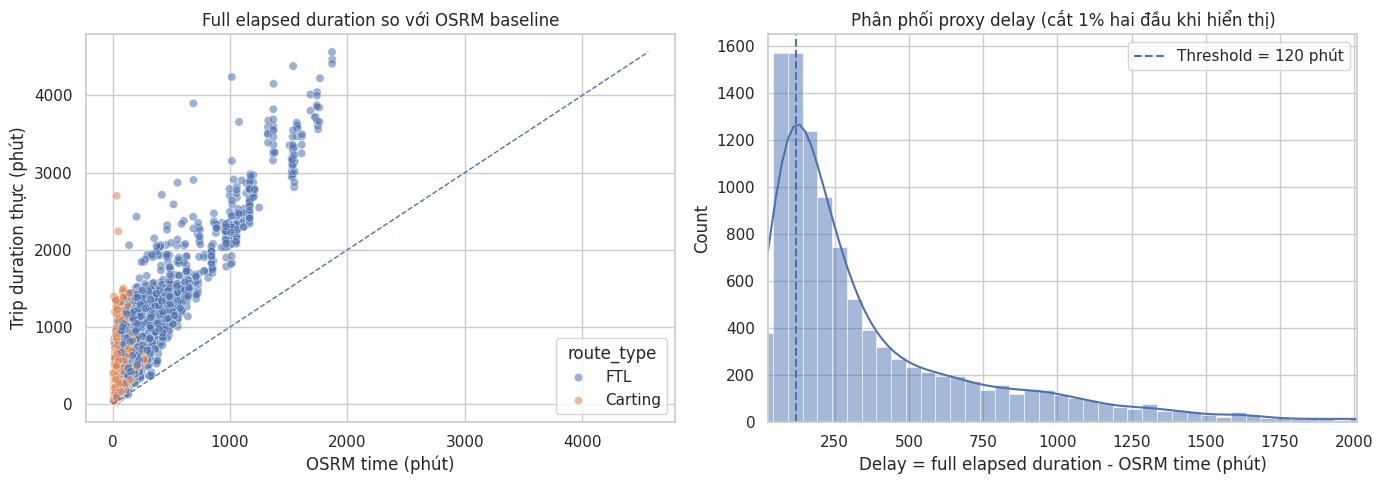

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = eda_df.sample(min(5000, len(eda_df)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample, x='osrm_time', y='trip_duration_minutes',
    hue='route_type', alpha=.55, ax=axes[0]
)
max_time = max(sample['osrm_time'].max(), sample['trip_duration_minutes'].max())
axes[0].plot([0, max_time], [0, max_time], linestyle='--', linewidth=1)
axes[0].set_title('Full elapsed duration versus OSRM baseline')
axes[0].set_xlabel('OSRM time (minutes)')
axes[0].set_ylabel('Actual trip duration (minutes)')

sns.histplot(eda_df['delay_minutes'], bins=80, kde=True, ax=axes[1], color='C0')
axes[1].axvline(
    DELAY_THRESHOLD_MINUTES, linestyle='--',
    label=f'Threshold = {DELAY_THRESHOLD_MINUTES} minutes'
)
axes[1].set_xlim(eda_df['delay_minutes'].quantile(.01), eda_df['delay_minutes'].quantile(.99))
axes[1].set_title('Proxy-delay distribution (1% trimmed from each tail)')
axes[1].set_xlabel('Delay = full elapsed duration - OSRM time (minutes)')
axes[1].legend()

plt.tight_layout()
plt.show()


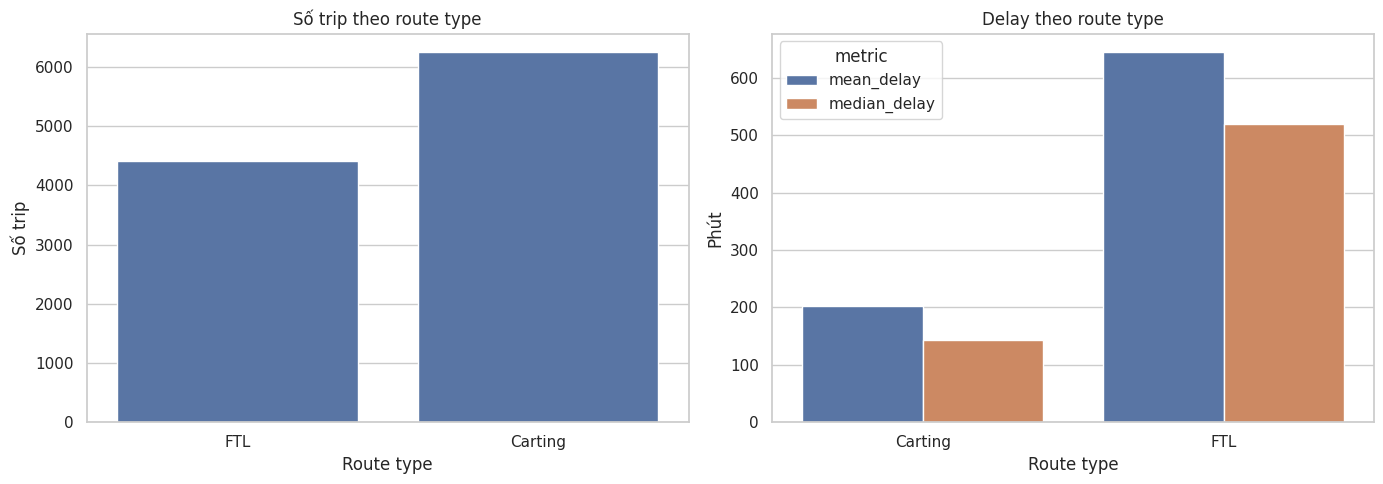

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=eda_df, x='route_type', ax=axes[0], color='C0')
axes[0].set_title('Trip count by route type')
axes[0].set_xlabel('Route type')
axes[0].set_ylabel('Number of trips')

route_delay = (
    eda_df.groupby('route_type', as_index=False)
           .agg(mean_delay=('delay_minutes', 'mean'), median_delay=('delay_minutes', 'median'))
)
route_delay_melt = route_delay.melt('route_type', var_name='metric', value_name='delay_minutes')
sns.barplot(data=route_delay_melt, x='route_type', y='delay_minutes', hue='metric', ax=axes[1], palette='deep')
axes[1].set_title('Delay theo route type')
axes[1].set_xlabel('Route type')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()


,state_corridor,trips,mean_delay,median_delay,mean_trip_duration
0,Karnataka → Haryana,27,"1,647.508","1,644.822","3,190.804"
1,Haryana → Karnataka,30,"1,577.163","1,599.011","3,119.597"
2,Haryana → West Bengal,25,"1,491.851","1,419.109","2,507.851"
3,Delhi → Maharashtra,27,"1,247.761","1,214.488","2,273.576"
4,Maharashtra → Haryana,36,"1,104.629","1,118.478","2,089.573"
5,Madhya Pradesh → Haryana,25,972.650,"1,237.674","1,587.010"
6,Telangana → Maharashtra,24,827.623,831.427,"1,346.457"
7,Maharashtra → Karnataka,25,817.416,846.134,"1,442.536"
8,Maharashtra → Telangana,39,786.736,800.324,"1,312.967"
9,Maharashtra → Goa,20,664.913,630.717,"1,053.913"


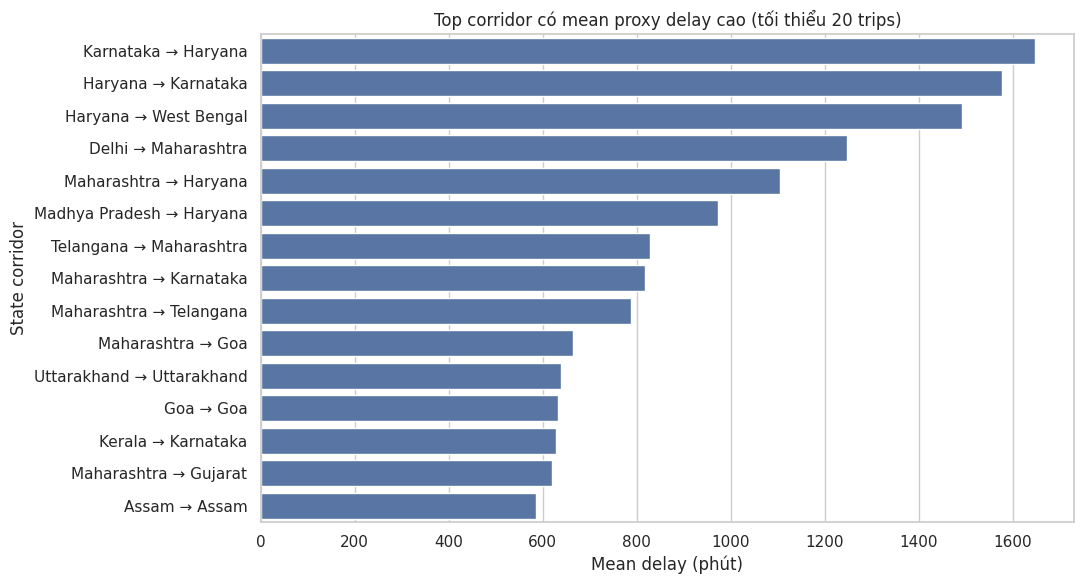

In [18]:
eda_df['state_corridor'] = eda_df['source_state'] + ' → ' + eda_df['destination_state']

corridor_summary = (
    eda_df.groupby('state_corridor')
           .agg(
               trips=('trip_uuid', 'size'),
               mean_delay=('delay_minutes', 'mean'),
               median_delay=('delay_minutes', 'median'),
               mean_trip_duration=('trip_duration_minutes', 'mean'),
           )
           .query('trips >= 20')
           .sort_values('mean_delay', ascending=False)
           .head(15)
           .reset_index()
)

display(corridor_summary)

plt.figure(figsize=(11, 6))
sns.barplot(data=corridor_summary, x='mean_delay', y='state_corridor', color='C0')
plt.title('Corridors with the highest mean proxy delay (minimum 20 trips)')
plt.xlabel('Mean delay (minutes)')
plt.ylabel('State corridor')
plt.tight_layout()
plt.show()


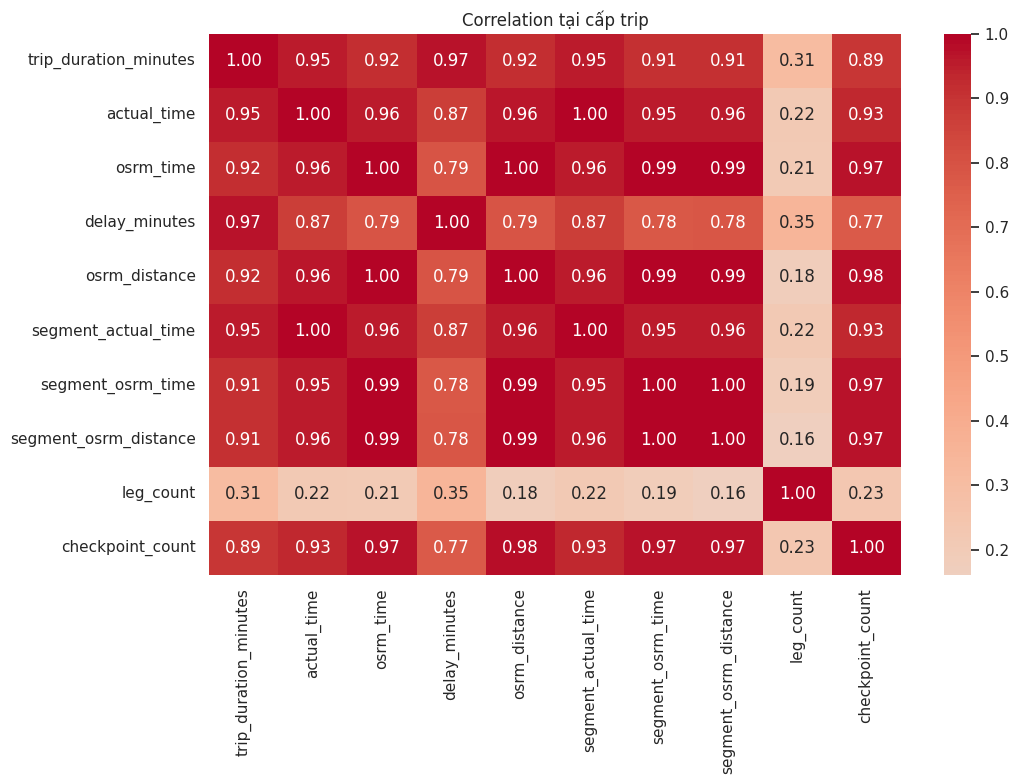

In [19]:
corr_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
    'segment_osrm_distance', 'leg_count', 'checkpoint_count'
]
plt.figure(figsize=(11, 8))
sns.heatmap(eda_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Trip-level correlation')
plt.tight_layout()
plt.show()


## 7. Feature Engineering


### Features Available at Trip Start

Only information known before or at departure is used:

- route-plan `osrm_time` and `osrm_distance`;
- origin, destination, and route type;
- departure hour and day;
- ratios derived only from the OSRM plan.

`segment_osrm_*`, `leg_count`, and `checkpoint_count` are excluded because they are aggregated from all observed rows and may not be fully known at departure. Actual, cutoff, and end-time variables are also excluded.


In [20]:
trip_df['start_hour'] = trip_df['trip_start_time'].dt.hour
trip_df['start_dayofweek'] = trip_df['trip_start_time'].dt.dayofweek
trip_df['start_month'] = trip_df['trip_start_time'].dt.month
trip_df['is_weekend'] = trip_df['start_dayofweek'].isin([5, 6]).astype(int)
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

trip_df['planned_speed_kmph'] = (
    trip_df['osrm_distance'] / (trip_df['osrm_time'] / 60).replace(0, np.nan)
)
trip_df['planned_minutes_per_km'] = (
    trip_df['osrm_time'] / trip_df['osrm_distance'].replace(0, np.nan)
)
trip_df = trip_df.replace([np.inf, -np.inf], np.nan)

START_NUMERIC_FEATURES = [
    'osrm_time', 'osrm_distance',
    'start_hour', 'start_dayofweek', 'start_month', 'is_weekend',
    'planned_speed_kmph', 'planned_minutes_per_km',
]

START_CATEGORICAL_FEATURES = [
    'route_type', 'source_state', 'destination_state', 'state_corridor'
]

START_FEATURES = START_NUMERIC_FEATURES + START_CATEGORICAL_FEATURES

print(f'Number of start-of-trip model features: {len(START_FEATURES)}')
display(trip_df[START_FEATURES + ['trip_duration_minutes', 'delay_minutes']].head())

Number of start-of-trip model features: 12


,osrm_time,osrm_distance,start_hour,start_dayofweek,start_month,is_weekend,planned_speed_kmph,planned_minutes_per_km,route_type,source_state,destination_state,state_corridor,trip_duration_minutes,delay_minutes
0,743.000,991.352,0,2,9,0,80.055,0.749,FTL,Madhya Pradesh,Haryana,Madhya Pradesh → Haryana,"2,260.110","1,517.110"
1,68.000,85.111,0,2,9,0,75.098,0.799,Carting,Karnataka,Karnataka,Karnataka → Karnataka,181.612,113.612
2,"1,741.000","2,372.085",0,2,9,0,81.749,0.734,FTL,Karnataka,Punjab,Karnataka → Punjab,"3,934.363","2,193.363"
3,15.000,19.680,0,2,9,0,78.720,0.762,Carting,Maharashtra,Maharashtra,Maharashtra → Maharashtra,100.495,85.495
4,117.000,146.792,0,2,9,0,75.278,0.797,FTL,Karnataka,Karnataka,Karnataka → Karnataka,718.349,601.349


## 8. Data Splitting and Leakage Prevention


The dataset provides an external time-based split:

- `training`: the earlier period;
- `test`: the later period.

The final test set is not used for EDA, feature selection, or threshold tuning. Within `training`, the notebook creates an additional chronological 80/20 fit-validation split for model evaluation and classification-threshold selection. After all decisions are fixed, each model is refitted on the full external training set and evaluated once on the final test set.


In [21]:
train_df = trip_df.query("data == 'training'").copy().sort_values('trip_creation_time')
test_df = trip_df.query("data == 'test'").copy().sort_values('trip_creation_time')

trip_overlap = set(train_df['trip_uuid']).intersection(test_df['trip_uuid'])
assert len(trip_overlap) == 0, 'Overlapping trip_uuid values found between external training and test sets.'


validation_start = int(len(train_df) * 0.80)
fit_df = train_df.iloc[:validation_start].copy()
validation_df = train_df.iloc[validation_start:].copy()

fit_val_overlap = set(fit_df['trip_uuid']).intersection(validation_df['trip_uuid'])
assert len(fit_val_overlap) == 0, 'Overlapping trip_uuid values found between fit and validation sets.'
assert fit_df['trip_creation_time'].max() <= validation_df['trip_creation_time'].min()

split_summary = pd.DataFrame({
    'split': ['fit', 'validation', 'final test'],
    'n_trips': [len(fit_df), len(validation_df), len(test_df)],
    'pct_all_trips': [len(fit_df)/len(trip_df), len(validation_df)/len(trip_df), len(test_df)/len(trip_df)],
    'start_date': [
        fit_df['trip_creation_time'].min(), validation_df['trip_creation_time'].min(),
        test_df['trip_creation_time'].min()
    ],
    'end_date': [
        fit_df['trip_creation_time'].max(), validation_df['trip_creation_time'].max(),
        test_df['trip_creation_time'].max()
    ],
    'mean_duration': [
        fit_df['trip_duration_minutes'].mean(), validation_df['trip_duration_minutes'].mean(),
        test_df['trip_duration_minutes'].mean()
    ],
    'mean_delay': [fit_df['delay_minutes'].mean(), validation_df['delay_minutes'].mean(), test_df['delay_minutes'].mean()],
})

display(split_summary)
print(f'External train trips: {len(train_df):,} ({len(train_df)/len(trip_df):.2%})')
print(f'Final test trips: {len(test_df):,} ({len(test_df)/len(trip_df):.2%})')
print(f'Trip overlap external train/test: {len(trip_overlap)}')

,split,n_trips,pct_all_trips,start_date,end_date,mean_duration,mean_delay
0,fit,8523,0.575,2018-09-12 00:00:16.535741,2018-09-23 22:15:46.635975,545.265,382.142
1,validation,2131,0.144,2018-09-23 22:16:47.064680,2018-09-26 23:54:27.945614,570.765,399.243
2,final test,4163,0.281,2018-09-27 00:02:18.970980,2018-10-03 23:59:42.701692,540.085,384.998


External train trips: 10,654 (71.90%)
Final test trips: 4,163 (28.10%)
Trip overlap external train/test: 0


### Leakage Guard

The following fields are **excluded from the start-of-trip ETA model**:

- `actual_time`, `segment_actual_time`, `actual_distance_to_destination`;
- `factor` and `segment_factor`, because they are derived directly from actual and planned time;
- `od_end_time`, `trip_end_time`, `start_scan_to_end_scan`;
- `cutoff_timestamp`, `cutoff_factor`, and `cutoff_rate` for predictions made before departure;
- `delay_minutes` and `actual_eta`, because they are targets or are derived from targets.


In [22]:
LEAKAGE_COLUMNS = {
    'actual_time', 'segment_actual_time', 'actual_distance_to_destination',
    'factor', 'segment_factor', 'od_end_time', 'trip_end_time',
    'start_scan_to_end_scan', 'cutoff_timestamp', 'cutoff_factor',
    'cutoff_rate', 'delay_minutes', 'delay_ratio', 'actual_eta',
    'trip_duration_minutes', 'actual_time_gap_vs_elapsed',
    'segment_osrm_time', 'segment_osrm_distance', 'leg_count', 'checkpoint_count'
}

leaked = LEAKAGE_COLUMNS.intersection(START_FEATURES)
assert not leaked, f'Feature set contains leakage or future information: {leaked}'
print('Start-of-trip leakage check passed.')

Start-of-trip leakage check passed.


In [23]:
def make_onehot_encoder(min_frequency):
    """Support multiple scikit-learn versions while preferring sparse output."""
    try:
        return OneHotEncoder(
            handle_unknown='ignore', min_frequency=min_frequency, sparse_output=True
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown='ignore', min_frequency=min_frequency, sparse=True
            )
        except TypeError:
            return OneHotEncoder(handle_unknown='ignore', sparse=True)


def make_start_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), START_NUMERIC_FEATURES),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', make_onehot_encoder(min_frequency=10)),
            ]), START_CATEGORICAL_FEATURES),
        ],
        remainder='drop',

        sparse_threshold=1.0,
    )


def ensure_sparse(X):
    """Always return a CSR sparse matrix without materializing the full dataset as dense."""
    if sparse.issparse(X):
        return X.tocsr()
    return sparse.csr_matrix(np.asarray(X, dtype=float))


def safe_roc_auc(y_true, probability):
    return roc_auc_score(y_true, probability) if pd.Series(y_true).nunique() > 1 else np.nan


def safe_average_precision(y_true, probability):
    return average_precision_score(y_true, probability) if np.any(np.asarray(y_true) == 1) else np.nan


def positive_class_probability(model, X):
    """Return the class-1 probability correctly even when the model was fitted on one class."""
    probability = np.asarray(model.predict_proba(X), dtype=float)
    classes = np.asarray(getattr(model, 'classes_', []))

    if classes.size == 1:
        return np.ones(X.shape[0], dtype=float) if classes[0] == 1 else np.zeros(X.shape[0], dtype=float)
    if probability.ndim == 1:
        return probability.reshape(-1)

    positive_positions = np.flatnonzero(classes == 1)
    if len(positive_positions) == 0:
        return np.zeros(X.shape[0], dtype=float)
    return probability[:, int(positive_positions[0])]


def fit_classifier_with_balancing(model, X, y):
    sample_weight = compute_sample_weight(class_weight='balanced', y=y)
    try:
        model.fit(X, y, sample_weight=sample_weight)
        return model, True
    except (TypeError, ValueError):
        model.fit(X, y)
        return model, False


def make_extra_trees_regressor():
    return ExtraTreesRegressor(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=2,
        max_features=1.0,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )


def make_extra_trees_classifier():
    return ExtraTreesClassifier(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=2,
        max_features=1.0,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )


model_inventory_df = pd.DataFrame([
    {'Task': 'ETA Prediction', 'Role': 'ML model', 'Model / baseline': 'Extra Trees Regressor'},
    {'Task': 'ETA Prediction', 'Role': 'Reference only', 'Model / baseline': 'OSRM baseline (no ML)'},
    {'Task': 'Severe Delay Classification', 'Role': 'ML model', 'Model / baseline': 'Extra Trees Classifier'},
    {'Task': 'Delay Propagation', 'Role': 'ML model', 'Model / baseline': 'Extra Trees Regressor (remaining delay)'},
    {'Task': 'Delay Propagation', 'Role': 'Reference only', 'Model / baseline': 'Current cumulative delay'},
])
display(model_inventory_df.style.set_caption('Model inventory — Extra Trees and reference baselines'))


,Task,Role,Model / baseline
0,ETA Prediction,ML model,Extra Trees Regressor
1,ETA Prediction,Reference only,OSRM baseline (no ML)
2,Severe Delay Classification,ML model,Extra Trees Classifier
3,Delay Propagation,ML model,Extra Trees Regressor (remaining delay)
4,Delay Propagation,Reference only,Current cumulative delay


## 9. ETA Prediction — Extra Trees Regressor


The ETA task uses an **Extra Trees Regressor** as its machine-learning model.

The notebook also reports an **OSRM baseline**, where `osrm_time` is used directly as the predicted duration. The OSRM baseline is not fitted and is not counted as a machine-learning model; it serves only as a reference for measuring the improvement delivered by Extra Trees.

Evaluation protocol:

- fit the validation model on the first 80% of the external training set (`fit_df`);
- evaluate Extra Trees and the OSRM baseline on the complete final 20% (`validation_df`);
- refit Extra Trees on the full external training set and evaluate it on the external final test set;
- do not shuffle the data or use the final test set for tuning;
- keep all preprocessed matrices sparse.


In [24]:
ETA_MODEL_NAME = 'Extra Trees Regressor'
print(f'ETA model: {ETA_MODEL_NAME}')


ETA model: Extra Trees Regressor


In [25]:
def _regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MedianAE': median_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


def duration_regression_metrics(y_true, y_pred):
    """Clip predicted durations at zero because duration cannot be negative."""
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0.0)
    return _regression_metrics(y_true, y_pred)


def delay_regression_metrics(y_true, y_pred):
    """Preserve negative delays because they represent early arrival."""
    return _regression_metrics(y_true, y_pred)





validation_preprocessor = make_start_preprocessor()
X_fit_t = ensure_sparse(
    validation_preprocessor.fit_transform(fit_df[START_FEATURES])
)
X_validation_t = ensure_sparse(
    validation_preprocessor.transform(validation_df[START_FEATURES])
)
y_fit_eta = fit_df['trip_duration_minutes'].to_numpy()
y_validation_eta = validation_df['trip_duration_minutes'].to_numpy()
osrm_validation_pred = validation_df['osrm_time'].to_numpy(dtype=float)

eta_validation_model = make_extra_trees_regressor()
validation_start_time = time.perf_counter()
eta_validation_model.fit(X_fit_t, y_fit_eta)
eta_validation_fit_seconds = time.perf_counter() - validation_start_time
eta_validation_pred = np.maximum(
    np.asarray(eta_validation_model.predict(X_validation_t), dtype=float), 0.0
)

eta_validation_results_df = pd.DataFrame([
    {
        'Model': ETA_MODEL_NAME,
        'Fit rows': len(fit_df),
        'Evaluation rows': len(validation_df),
        'Fit seconds': eta_validation_fit_seconds,
        **duration_regression_metrics(y_validation_eta, eta_validation_pred),
    },
    {
        'Model': 'OSRM baseline (no ML)',
        'Fit rows': 0,
        'Evaluation rows': len(validation_df),
        'Fit seconds': 0.0,
        **duration_regression_metrics(y_validation_eta, osrm_validation_pred),
    },
]).sort_values('MAE').reset_index(drop=True)

display(eta_validation_results_df.style.set_caption(
    'ETA validation — Extra Trees versus OSRM baseline on the full validation set'
))


deployment_eta_model_name = ETA_MODEL_NAME




start_preprocessor = make_start_preprocessor()
X_train_t = ensure_sparse(
    start_preprocessor.fit_transform(train_df[START_FEATURES])
)
X_test_t = ensure_sparse(
    start_preprocessor.transform(test_df[START_FEATURES])
)
feature_names = start_preprocessor.get_feature_names_out()
y_train_eta = train_df['trip_duration_minutes'].to_numpy()
y_test_eta = test_df['trip_duration_minutes'].to_numpy()
osrm_test_pred = test_df['osrm_time'].to_numpy(dtype=float)

final_eta_model = make_extra_trees_regressor()
final_fit_start_time = time.perf_counter()
final_eta_model.fit(X_train_t, y_train_eta)
eta_final_fit_seconds = time.perf_counter() - final_fit_start_time
best_eta_pred = np.maximum(
    np.asarray(final_eta_model.predict(X_test_t), dtype=float), 0.0
)

eta_test_results_df = pd.DataFrame([
    {
        'Model': ETA_MODEL_NAME,
        'Fit rows': len(train_df),
        'Evaluation rows': len(test_df),
        'Fit seconds': eta_final_fit_seconds,
        **duration_regression_metrics(y_test_eta, best_eta_pred),
    },
    {
        'Model': 'OSRM baseline (no ML)',
        'Fit rows': 0,
        'Evaluation rows': len(test_df),
        'Fit seconds': 0.0,
        **duration_regression_metrics(y_test_eta, osrm_test_pred),
    },
]).sort_values('MAE').reset_index(drop=True)

display(eta_test_results_df.style.set_caption(
    'ETA final test — Extra Trees versus OSRM baseline'
))

final_eta_model_matrix_kind = 'sparse CSR'
print(f'Transformed fit matrix: {type(X_fit_t).__name__}, sparse={sparse.issparse(X_fit_t)}, shape={X_fit_t.shape}')
print(f'Transformed validation matrix: {type(X_validation_t).__name__}, sparse={sparse.issparse(X_validation_t)}, shape={X_validation_t.shape}')
print(f'Transformed full train matrix: {type(X_train_t).__name__}, sparse={sparse.issparse(X_train_t)}, shape={X_train_t.shape}')
print(f'Transformed final test matrix: {type(X_test_t).__name__}, sparse={sparse.issparse(X_test_t)}, shape={X_test_t.shape}')
print(f'Deployment ETA model: {deployment_eta_model_name}')


,Model,Fit rows,Evaluation rows,Fit seconds,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,8523,2131,29.815329,101.735702,52.718286,183.093811,0.926177
1,OSRM baseline (no ML),0,2131,0.000000,399.251664,228.954665,584.855719,0.246747


,Model,Fit rows,Evaluation rows,Fit seconds,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,10654,4163,41.246758,104.925153,53.040828,223.811162,0.897881
1,OSRM baseline (no ML),0,4163,0.000000,384.997853,208.914406,599.942470,0.266225


Transformed fit matrix: csr_matrix, sparse=True, shape=(8523, 138)
Transformed validation matrix: csr_matrix, sparse=True, shape=(2131, 138)
Transformed full train matrix: csr_matrix, sparse=True, shape=(10654, 157)
Transformed final test matrix: csr_matrix, sparse=True, shape=(4163, 157)
Deployment ETA model: Extra Trees Regressor


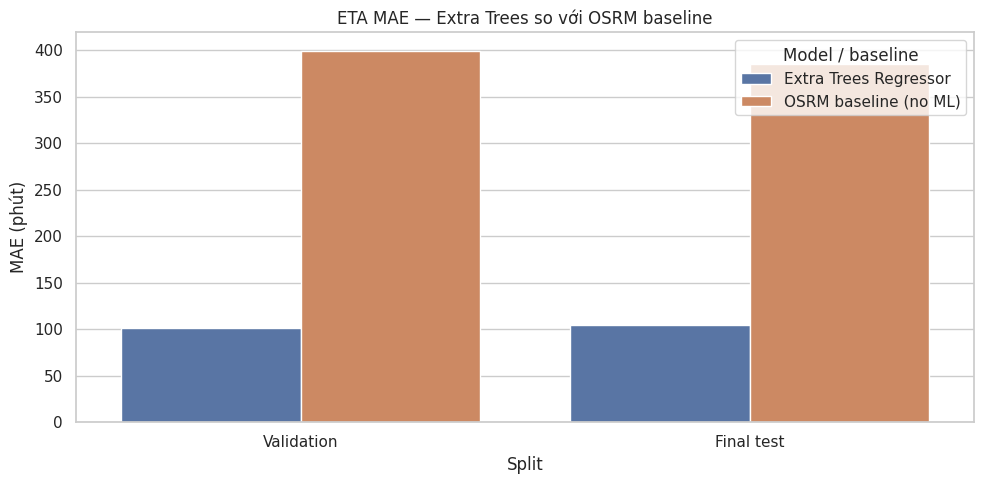

In [26]:
eta_comparison_df = pd.concat([
    eta_validation_results_df.assign(Split='Validation'),
    eta_test_results_df.assign(Split='Final test'),
], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=eta_comparison_df, x='Split', y='MAE', hue='Model')
plt.title('ETA MAE — Extra Trees versus OSRM baseline')
plt.ylabel('MAE (minutes)')
plt.legend(title='Model / baseline')
plt.tight_layout()
plt.show()


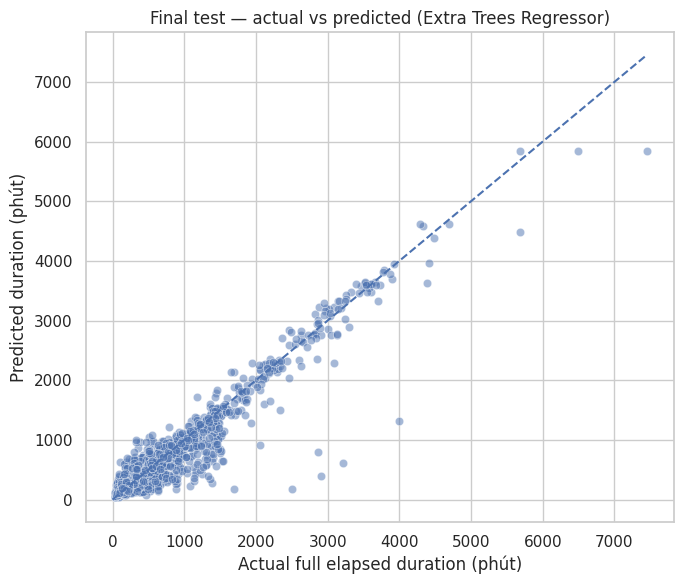

In [27]:
plot_df = pd.DataFrame({
    'Actual': np.asarray(y_test_eta),
    'Predicted': np.asarray(best_eta_pred),
}).sample(min(2500, len(test_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x='Actual', y='Predicted', alpha=.5, color='C0')
max_value = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
plt.plot([0, max_value], [0, max_value], linestyle='--')
plt.title('Final test — actual vs predicted (Extra Trees Regressor)')
plt.xlabel('Actual full elapsed duration (minutes)')
plt.ylabel('Predicted duration (minutes)')
plt.tight_layout()
plt.show()


## 10. Delay Magnitude Estimation


Delay magnitude is derived directly from the same ETA or duration prediction:

\[
\widehat{Delay} = \widehat{Duration} - OSRMTime
\]

This definition keeps predicted ETA and predicted delay algebraically consistent. It represents a **proxy delay relative to the OSRM routing baseline**, not an official SLA delay.


In [28]:
y_test_delay = test_df['delay_minutes']


delay_pred = best_eta_pred - test_df['osrm_time'].to_numpy()



delay_results_df = pd.DataFrame([
    {
        'Model': 'Zero-delay / OSRM baseline',
        **delay_regression_metrics(y_test_delay, np.zeros(len(y_test_delay)))
    },
    {
        'Model': f'Derived from {deployment_eta_model_name}',
        **delay_regression_metrics(y_test_delay, delay_pred)
    },
]).sort_values('MAE').reset_index(drop=True)

display(delay_results_df.style.set_caption(
    'Final test — proxy delay magnitude with negative predictions preserved'
))


,Model,MAE,MedianAE,RMSE,R2
0,Derived from Extra Trees Regressor,104.925153,53.040828,223.811162,0.763393
1,Zero-delay / OSRM baseline,384.997853,208.914406,599.942470,-0.700132


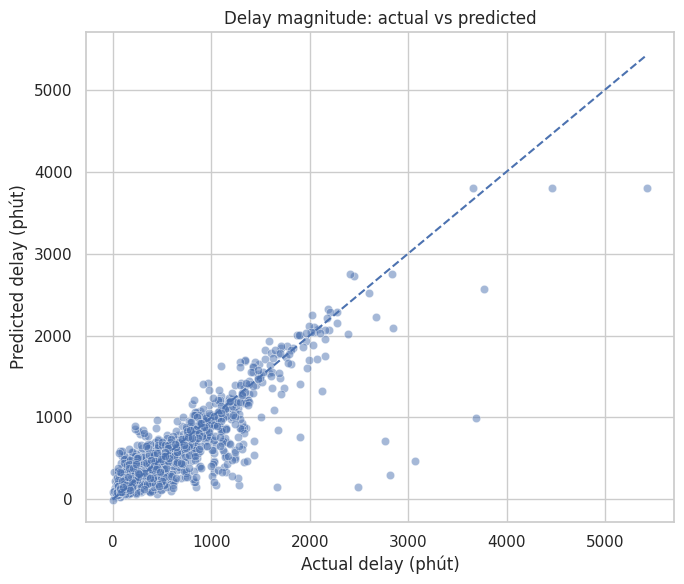

In [29]:
delay_plot = pd.DataFrame({
    'Actual delay': y_test_delay.to_numpy(),
    'Predicted delay': delay_pred,
}).sample(min(2500, len(test_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=delay_plot, x='Actual delay', y='Predicted delay', alpha=.5, color='C0')
low = min(delay_plot.min())
high = max(delay_plot.max())
plt.plot([low, high], [low, high], linestyle='--')
plt.title('Delay magnitude: actual vs predicted')
plt.xlabel('Actual delay (minutes)')
plt.ylabel('Predicted delay (minutes)')
plt.tight_layout()
plt.show()

## 11. Severe Delay Classification — Extra Trees Classifier


The classification task uses only an **Extra Trees Classifier**.

- Fit the validation model on `fit_df` and predict the complete `validation_df`.
- Select the probability threshold that maximizes validation F1.
- Refit the classifier on the full external training set.
- Apply the fixed validation threshold to the external final test set.


In [30]:
CLASSIFIER_MODEL_NAME = 'Extra Trees Classifier'
print(f'Severe delay label: delay_minutes > {DELAY_THRESHOLD_MINUTES} minutes')
print(f'Classifier: {CLASSIFIER_MODEL_NAME}')


Severe delay label: delay_minutes > 120 phút
Classifier: Extra Trees Classifier


In [31]:
def classification_metrics_at_threshold(y_true, probability, threshold):
    pred = (np.asarray(probability) >= threshold).astype(int)
    return {
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'ROC_AUC': safe_roc_auc(y_true, probability),
        'PR_AUC': safe_average_precision(y_true, probability),
    }


def optimize_probability_threshold(y_true, probability):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 91):
        rows.append({
            'Threshold': threshold,
            **classification_metrics_at_threshold(y_true, probability, threshold),
        })
    table = pd.DataFrame(rows)
    best = table.sort_values(
        ['F1', 'Recall', 'Precision'], ascending=False
    ).iloc[0]
    return float(best['Threshold']), table





y_fit_cls = (fit_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()
y_validation_cls = (
    validation_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES
).astype(int).to_numpy()

if np.unique(y_fit_cls).size < 2:
    print('Warning: the fit split contains only one class; probabilities are handled safely, but classification metrics are limited.')
if np.unique(y_validation_cls).size < 2:
    print('Warning: the validation split contains only one class; ROC-AUC and PR-AUC may be undefined.')

classifier_validation_model, validation_balanced_used = fit_classifier_with_balancing(
    make_extra_trees_classifier(), X_fit_t, y_fit_cls
)
classifier_validation_probability = positive_class_probability(
    classifier_validation_model, X_validation_t
)
best_classification_threshold, classifier_threshold_table = optimize_probability_threshold(
    y_validation_cls, classifier_validation_probability
)
classifier_validation_pred = (
    classifier_validation_probability >= best_classification_threshold
).astype(int)

classifier_validation_results_df = pd.DataFrame([{
    'Model': CLASSIFIER_MODEL_NAME,
    'ProbabilityThreshold': best_classification_threshold,
    'BalancedWeightUsed': validation_balanced_used,
    'Fit rows': len(fit_df),
    'Evaluation rows': len(validation_df),
    **classification_metrics_at_threshold(
        y_validation_cls,
        classifier_validation_probability,
        best_classification_threshold,
    ),
}])
display(classifier_validation_results_df.style.set_caption(
    'Severe-delay validation — Extra Trees Classifier'
))

best_classifier_name = CLASSIFIER_MODEL_NAME




y_train_cls = (train_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()
y_test_cls = (test_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int).to_numpy()

if np.unique(y_train_cls).size < 2:
    print('Warning: external training contains only one class; the classifier can be fitted but cannot learn a two-class boundary.')

classifier, final_balanced_used = fit_classifier_with_balancing(
    make_extra_trees_classifier(), X_train_t, y_train_cls
)
classifier_matrix_kind = 'sparse CSR'
severe_delay_probability = positive_class_probability(classifier, X_test_t)
severe_delay_pred = (
    severe_delay_probability >= best_classification_threshold
).astype(int)

classification_test_results_df = pd.DataFrame([{
    'Model': CLASSIFIER_MODEL_NAME,
    'ProbabilityThreshold': best_classification_threshold,
    'BalancedWeightUsed': final_balanced_used,
    'Fit rows': len(train_df),
    'Evaluation rows': len(test_df),
    **classification_metrics_at_threshold(
        y_test_cls,
        severe_delay_probability,
        best_classification_threshold,
    ),
}])
display(classification_test_results_df.style.set_caption(
    'Severe-delay final test — Extra Trees Classifier'
))

classification_metrics = classification_test_results_df.copy()
print(f'Train positive rate: {y_train_cls.mean():.2%}')
print(f'Test positive rate: {y_test_cls.mean():.2%}')
print(f'Deployment classifier: {best_classifier_name}')
print(f'Probability threshold selected on validation: {best_classification_threshold:.2f}')
print(classification_report(y_test_cls, severe_delay_pred, digits=3, zero_division=0))


,Model,ProbabilityThreshold,BalancedWeightUsed,Fit rows,Evaluation rows,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,0.340000,True,8523,2131,0.862037,0.889091,0.929658,0.908922,0.921647,0.971867


,Model,ProbabilityThreshold,BalancedWeightUsed,Fit rows,Evaluation rows,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,0.340000,True,10654,4163,0.852270,0.877271,0.922871,0.899493,0.911389,0.964200


Train positive rate: 72.66%
Test positive rate: 71.63%
Deployment classifier: Extra Trees Classifier
Probability threshold selected on validation: 0.34
              precision    recall  f1-score   support

           0      0.776     0.674     0.721      1181
           1      0.877     0.923     0.899      2982

    accuracy                          0.852      4163
   macro avg      0.827     0.798     0.810      4163
weighted avg      0.848     0.852     0.849      4163



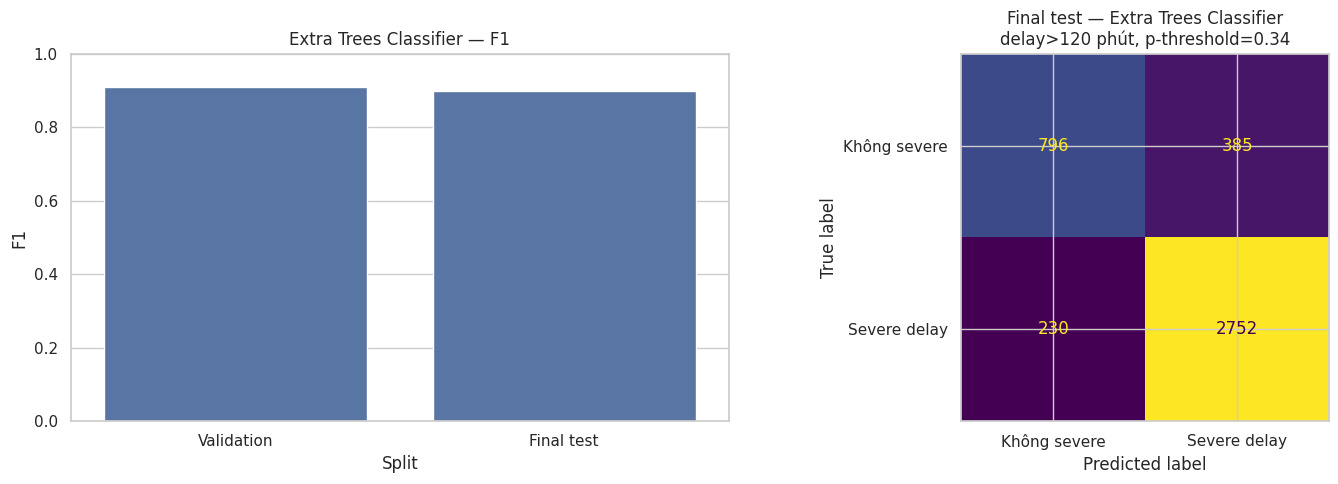

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metric_plot = pd.concat([
    classifier_validation_results_df.assign(Split='Validation'),
    classification_test_results_df.assign(Split='Final test'),
], ignore_index=True)
sns.barplot(data=metric_plot, x='Split', y='F1', ax=axes[0], color='C0')
axes[0].set_title('Extra Trees Classifier — F1')
axes[0].set_ylim(0, 1)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_cls, severe_delay_pred, labels=[0, 1]),
    display_labels=['Not severe', 'Severe delay']
).plot(ax=axes[1], values_format='d', colorbar=False)
axes[1].set_title(
    f'Final test — Extra Trees Classifier\n'
    f'delay>{DELAY_THRESHOLD_MINUTES} minutes, p-threshold={best_classification_threshold:.2f}'
)

plt.tight_layout()
plt.show()


## 12. Delay Propagation — Extra Trees Regressor

The propagation model predicts the **remaining delay** after the current checkpoint rather than predicting final delay directly. Predicted final delay is calculated as:

\[
\widehat{FinalDelay}_k = CumulativeStageDelay_k + \widehat{RemainingDelay}_k
\]

Results are compared with the non-machine-learning baseline `FinalDelay = CumulativeStageDelay`, which assumes that no additional downstream delay will occur.


The start-of-trip model uses planned information only. To represent delay propagation, the notebook creates a snapshot after each observed checkpoint.

At checkpoint \(k\):

\[
StageDelay_k = SegmentActualTime_k - SegmentOSRMTime_k
\]

\[
CumulativeStageDelay_k = \sum_{i=1}^{k} StageDelay_i
\]

\[
RemainingDelay_k = FinalDelay - CumulativeStageDelay_k
\]

Checkpoints within each leg are sorted by ascending `actual_time`. Progress and remaining planned time use `trip_osrm_time`, which is the full-trip plan known at departure; future checkpoint rows are not summed to create the denominator. Final metrics are reported at 25%, 50%, 75%, and 100% progress, with one observation per trip at each milestone.


In [33]:

stage_df = df.query('segment_actual_time >= 0 and segment_osrm_time > 0').copy()


stage_df = stage_df.sort_values(
    ['trip_uuid', 'od_start_time', 'actual_time', 'cutoff_timestamp', '_row_order'],
    ascending=[True, True, True, False, True],
    na_position='last',
).reset_index(drop=True)

trip_targets = trip_df[[
    'trip_uuid', 'trip_duration_minutes', 'osrm_time', 'osrm_distance', 'delay_minutes'
]].rename(columns={
    'trip_duration_minutes': 'final_trip_duration',
    'osrm_time': 'trip_osrm_time',
    'osrm_distance': 'trip_osrm_distance',
    'delay_minutes': 'final_delay_minutes',
})

stage_df = stage_df.merge(trip_targets, on='trip_uuid', how='inner')
stage_group = stage_df.groupby('trip_uuid', sort=False)

stage_df['stage_index'] = stage_group.cumcount() + 1
stage_df['cum_actual_time'] = stage_group['segment_actual_time'].cumsum()
stage_df['cum_osrm_time'] = stage_group['segment_osrm_time'].cumsum()
stage_df['current_stage_delay'] = stage_df['segment_actual_time'] - stage_df['segment_osrm_time']
stage_df['cum_stage_delay'] = stage_df['cum_actual_time'] - stage_df['cum_osrm_time']
stage_df['previous_stage_delay'] = (
    stage_df.groupby('trip_uuid', sort=False)['current_stage_delay'].shift(1).fillna(0)
)


stage_df['progress_ratio'] = (
    stage_df['cum_osrm_time'] /
    stage_df['trip_osrm_time'].replace(0, np.nan)
).clip(0, 1)
stage_df['remaining_trip_plan_time'] = (
    stage_df['trip_osrm_time'] - stage_df['cum_osrm_time']
).clip(lower=0)


stage_df['remaining_delay_minutes'] = (
    stage_df['final_delay_minutes'] - stage_df['cum_stage_delay']
)

stage_df['start_hour'] = stage_df['od_start_time'].dt.hour
stage_df['start_dayofweek'] = stage_df['od_start_time'].dt.dayofweek

STAGE_NUMERIC_FEATURES = [
    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
    'current_stage_delay', 'previous_stage_delay',
    'cum_actual_time', 'cum_osrm_time', 'cum_stage_delay',
    'progress_ratio', 'remaining_trip_plan_time',
    'stage_index',
    'trip_osrm_time', 'trip_osrm_distance',
    'start_hour', 'start_dayofweek',
]
STAGE_CATEGORICAL_FEATURES = ['route_type', 'source_state', 'destination_state']
STAGE_FEATURES = STAGE_NUMERIC_FEATURES + STAGE_CATEGORICAL_FEATURES

assert 'total_stages' not in STAGE_FEATURES
assert 'total_segment_osrm_time' not in STAGE_FEATURES
assert stage_df['progress_ratio'].between(0, 1).all()

print(f'Stage-level shape after quality filters: {stage_df.shape}')
print(f'Unique stage trips: {stage_df.trip_uuid.nunique():,}')
print(f'Rows excluded by stage quality/target rules: {len(df) - len(stage_df):,}')
display(stage_df[STAGE_FEATURES + [
    'cum_stage_delay', 'remaining_delay_minutes', 'final_delay_minutes'
]].head())


Stage-level shape after quality filters: (142502, 46)
Unique stage trips: 14,817
Rows excluded by stage quality/target rules: 2,365


,segment_actual_time,segment_osrm_time,segment_osrm_distance,current_stage_delay,previous_stage_delay,cum_actual_time,cum_osrm_time,cum_stage_delay,progress_ratio,remaining_trip_plan_time,stage_index,trip_osrm_time,trip_osrm_distance,start_hour,start_dayofweek,route_type,source_state,destination_state,cum_stage_delay,remaining_delay_minutes,final_delay_minutes
0,43.000,39.000,55.260,4.000,0.000,43.000,39.000,4.000,0.052,704.000,1,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,4.000,"1,513.110","1,517.110"
1,25.000,52.000,73.865,-27.000,4.000,68.000,91.000,-23.000,0.122,652.000,2,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,-23.000,"1,540.110","1,517.110"
2,76.000,16.000,23.063,60.000,-27.000,144.000,107.000,37.000,0.144,636.000,3,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,37.000,"1,480.110","1,517.110"
3,35.000,15.000,21.416,20.000,60.000,179.000,122.000,57.000,0.164,621.000,4,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,57.000,"1,460.110","1,517.110"
4,23.000,16.000,23.269,7.000,20.000,202.000,138.000,64.000,0.186,605.000,5,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,64.000,"1,453.110","1,517.110"


In [34]:
stage_train = stage_df.query("data == 'training'").copy().reset_index(drop=True)
stage_test = stage_df.query("data == 'test'").copy().reset_index(drop=True)

stage_overlap = set(stage_train['trip_uuid']).intersection(stage_test['trip_uuid'])
assert len(stage_overlap) == 0, 'Overlapping trip_uuid values found between stage training and test sets.'

stage_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), STAGE_NUMERIC_FEATURES),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_onehot_encoder(min_frequency=20)),
        ]), STAGE_CATEGORICAL_FEATURES),
    ],
    sparse_threshold=1.0,
)

X_stage_train_t = ensure_sparse(
    stage_preprocessor.fit_transform(stage_train[STAGE_FEATURES])
)
X_stage_test_t = ensure_sparse(
    stage_preprocessor.transform(stage_test[STAGE_FEATURES])
)
stage_feature_names = stage_preprocessor.get_feature_names_out()
print(f'Stage train matrix: {type(X_stage_train_t).__name__}, sparse={sparse.issparse(X_stage_train_t)}, shape={X_stage_train_t.shape}')
print(f'Stage test matrix: {type(X_stage_test_t).__name__}, sparse={sparse.issparse(X_stage_test_t)}, shape={X_stage_test_t.shape}')

propagation_model_name = 'Extra Trees Regressor (remaining delay)'
propagation_model = ExtraTreesRegressor(
    n_estimators=180,
    max_depth=None,
    min_samples_leaf=2,
    max_features=1.0,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)


train_stage_count = stage_train.groupby('trip_uuid')['trip_uuid'].transform('size')
stage_sample_weight = 1.0 / train_stage_count
stage_sample_weight = stage_sample_weight / stage_sample_weight.mean()

propagation_model.fit(
    X_stage_train_t,
    stage_train['remaining_delay_minutes'],
    sample_weight=stage_sample_weight,
)

predicted_remaining_delay = propagation_model.predict(X_stage_test_t)
predicted_final_delay = stage_test['cum_stage_delay'].to_numpy() + predicted_remaining_delay
baseline_final_delay = stage_test['cum_stage_delay'].to_numpy()

predicted_remaining_delay_series = pd.Series(
    predicted_remaining_delay, index=stage_test.index, name='predicted_remaining_delay'
)
predicted_final_delay_series = pd.Series(
    predicted_final_delay, index=stage_test.index, name='predicted_final_delay'
)
baseline_final_delay_series = pd.Series(
    baseline_final_delay, index=stage_test.index, name='baseline_final_delay'
)

print(f'Propagation model: {propagation_model_name}')
print(f'Stage train rows: {len(stage_train):,}; trips: {stage_train.trip_uuid.nunique():,}')
print(f'Stage test rows: {len(stage_test):,}; trips: {stage_test.trip_uuid.nunique():,}')
print(f'Stage trip overlap train/test: {len(stage_overlap)}')


Stage train matrix: csr_matrix, sparse=True, shape=(103126, 80)
Stage test matrix: csr_matrix, sparse=True, shape=(39376, 80)
Propagation model: Extra Trees Regressor (remaining delay)
Stage train rows: 103,126; trips: 10,654
Stage test rows: 39,376; trips: 4,163
Stage trip overlap train/test: 0


,Checkpoint,Trips,Mean selected progress,Model,MAE,MedianAE,RMSE,R2
0,25%,4163,0.383,Extra Trees Regressor (remaining delay),100.799,49.973,205.847,0.800
1,25%,4163,0.383,Current cumulative delay baseline,348.240,186.458,539.149,-0.373
2,50%,4163,0.498,Extra Trees Regressor (remaining delay),100.131,50.527,202.672,0.806
3,50%,4163,0.498,Current cumulative delay baseline,322.524,177.117,492.944,-0.148
4,75%,4163,0.654,Extra Trees Regressor (remaining delay),98.069,49.421,200.434,0.810
5,75%,4163,0.654,Current cumulative delay baseline,293.037,164.606,445.890,0.061
6,100%,4163,0.989,Extra Trees Regressor (remaining delay),85.954,44.601,177.170,0.852
7,100%,4163,0.989,Current cumulative delay baseline,230.399,130.711,357.392,0.397


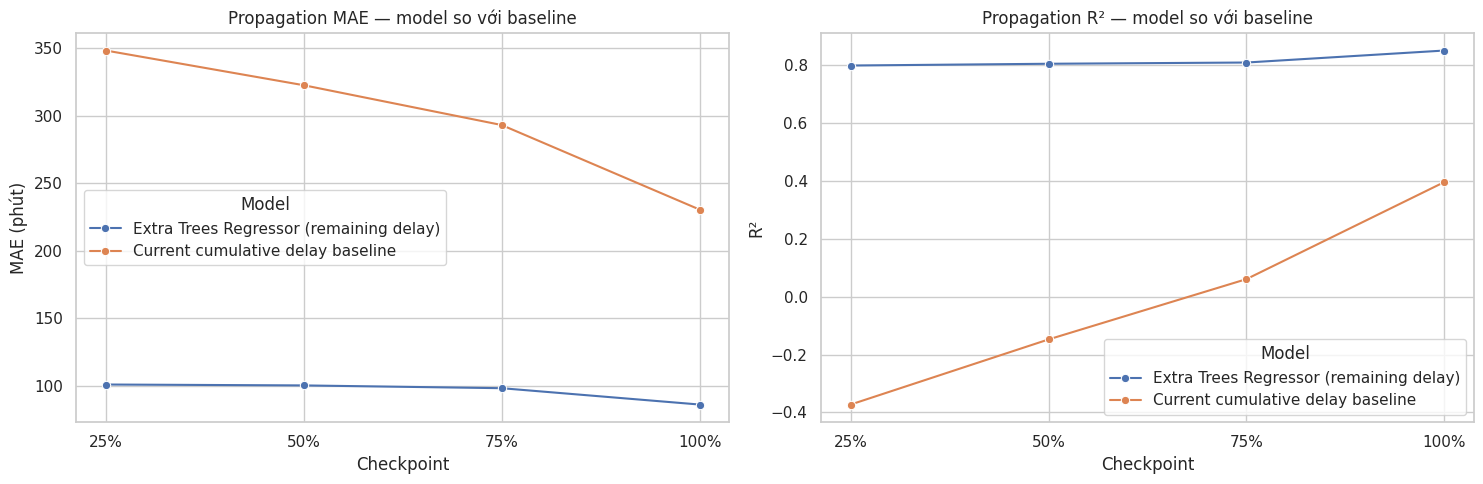

In [35]:
def select_one_checkpoint_per_trip(frame, target_progress):
    """Select the latest checkpoint not exceeding the milestone; otherwise select the earliest checkpoint."""
    selected_indices = []
    for _, group in frame.groupby('trip_uuid', sort=False):
        eligible = group.loc[group['progress_ratio'] <= target_progress + 1e-12]
        if eligible.empty:
            selected_index = group['progress_ratio'].idxmin()
        else:
            selected_index = eligible['progress_ratio'].idxmax()
        selected_indices.append(selected_index)
    return pd.Index(selected_indices)


checkpoint_results = []
checkpoint_predictions = {}
for target_progress, label in [
    (0.25, '25%'),
    (0.50, '50%'),
    (0.75, '75%'),
    (1.00, '100%'),
]:
    selected_index = select_one_checkpoint_per_trip(stage_test, target_progress)
    selected = stage_test.loc[selected_index]
    model_pred = predicted_final_delay_series.loc[selected_index].to_numpy()
    baseline_pred = baseline_final_delay_series.loc[selected_index].to_numpy()
    remaining_pred = predicted_remaining_delay_series.loc[selected_index].to_numpy()
    checkpoint_predictions[label] = {
        'rows': selected,
        'predicted_remaining_delay': remaining_pred,
        'predicted_final_delay': model_pred,
        'baseline_final_delay': baseline_pred,
    }

    common = {
        'Checkpoint': label,
        'Trips': selected['trip_uuid'].nunique(),
        'Mean selected progress': selected['progress_ratio'].mean(),
    }
    checkpoint_results.append({
        **common,
        'Model': propagation_model_name,
        **delay_regression_metrics(selected['final_delay_minutes'], model_pred),
    })
    checkpoint_results.append({
        **common,
        'Model': 'Current cumulative delay baseline',
        **delay_regression_metrics(selected['final_delay_minutes'], baseline_pred),
    })

checkpoint_results_df = pd.DataFrame(checkpoint_results)
display(checkpoint_results_df)

assert checkpoint_results_df['Trips'].max() <= stage_test['trip_uuid'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(
    data=checkpoint_results_df, x='Checkpoint', y='MAE', hue='Model',
    marker='o', ax=axes[0]
)
axes[0].set_title('Propagation MAE — model versus baseline')
axes[0].set_ylabel('MAE (minutes)')

sns.lineplot(
    data=checkpoint_results_df, x='Checkpoint', y='R2', hue='Model',
    marker='o', ax=axes[1]
)
axes[1].set_title('Propagation R² — model versus baseline')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()


## 13. Explainability


The solution provides two levels of explanation:

1. **Global feature importance** from Extra Trees for ETA prediction, severe-delay classification, and remaining-delay propagation. This is always available and requires no additional package.
2. **Local SHAP explanations** for one shipment-level ETA prediction and one propagation checkpoint. These run when `shap` is available. Otherwise, the notebook still presents the selected shipment or checkpoint together with the most important global factors.

Feature importance measures relative model contribution and does not establish causality.


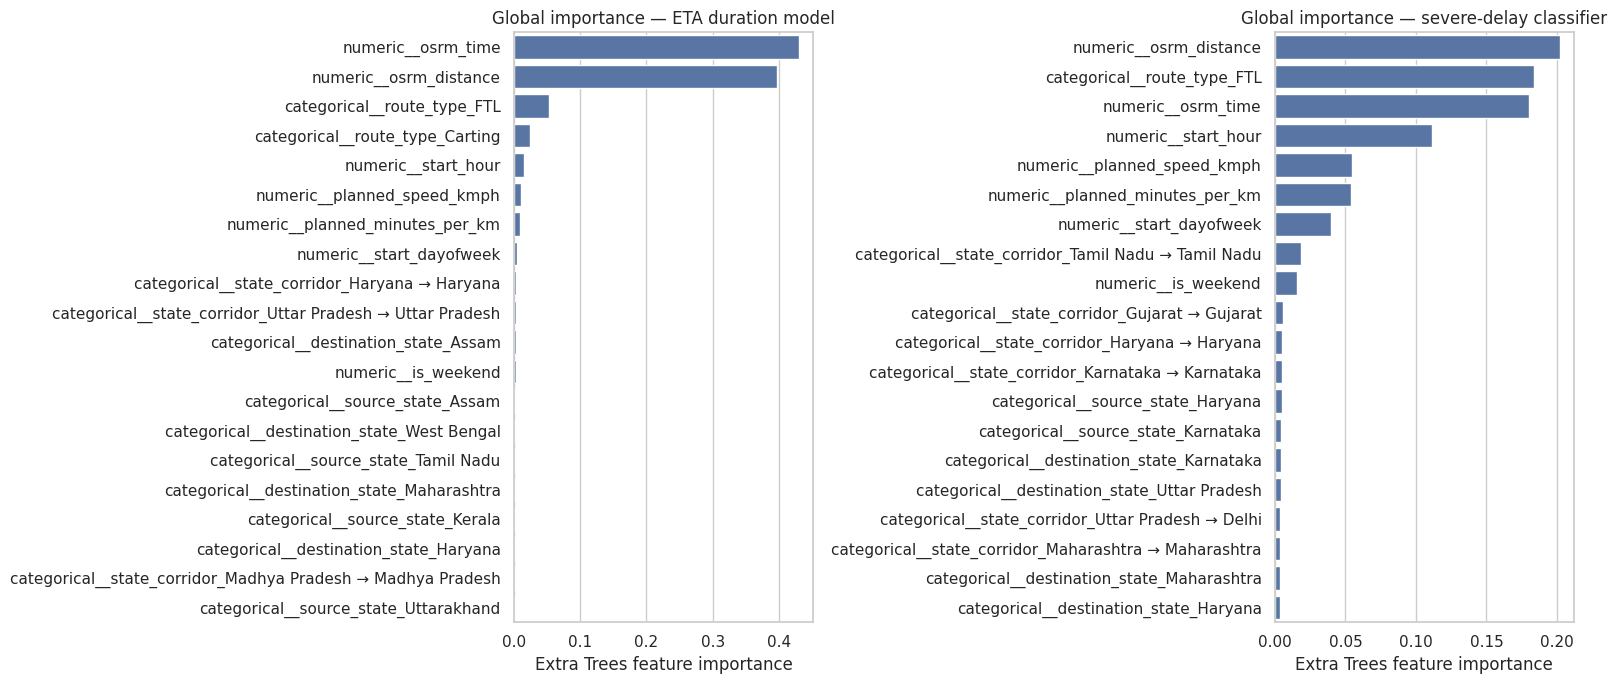

,feature,importance
0,numeric__osrm_time,0.429909
1,numeric__osrm_distance,0.396397
2,categorical__route_type_FTL,0.053336
3,categorical__route_type_Carting,0.024160
4,numeric__start_hour,0.015270
5,numeric__planned_speed_kmph,0.010169
6,numeric__planned_minutes_per_km,0.008794
7,numeric__start_dayofweek,0.004471
8,categorical__state_corridor_Haryana → Haryana,0.003320
9,categorical__state_corridor_Uttar Pradesh → Uttar Pradesh,0.003169


,feature,importance
0,numeric__osrm_distance,0.201914
1,categorical__route_type_FTL,0.183701
2,numeric__osrm_time,0.179773
3,numeric__start_hour,0.111266
4,numeric__planned_speed_kmph,0.054844
5,numeric__planned_minutes_per_km,0.054160
6,numeric__start_dayofweek,0.039799
7,categorical__state_corridor_Tamil Nadu → Tamil Nadu,0.018904
8,numeric__is_weekend,0.015816
9,categorical__state_corridor_Gujarat → Gujarat,0.005878


In [36]:
def build_feature_importance_table(model, names, top_n=20):
    table = pd.DataFrame({
        'feature': np.asarray(names, dtype=str),
        'importance': np.asarray(model.feature_importances_, dtype=float),
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    return table.head(top_n)


eta_feature_importance_df = build_feature_importance_table(
    final_eta_model, feature_names, top_n=20
)
classifier_feature_importance_df = build_feature_importance_table(
    classifier, feature_names, top_n=20
)
propagation_feature_importance_df = build_feature_importance_table(
    propagation_model, stage_feature_names, top_n=20
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(
    data=eta_feature_importance_df, x='importance', y='feature',
    ax=axes[0], color='C0'
)
axes[0].set_title('Global importance — ETA duration model')
axes[0].set_xlabel('Extra Trees feature importance')
axes[0].set_ylabel('')

sns.barplot(
    data=classifier_feature_importance_df, x='importance', y='feature',
    ax=axes[1], color='C0'
)
axes[1].set_title('Global importance — severe-delay classifier')
axes[1].set_xlabel('Extra Trees feature importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

display(eta_feature_importance_df.style.set_caption('Top ETA factors'))
display(classifier_feature_importance_df.style.set_caption('Top severe-delay factors'))


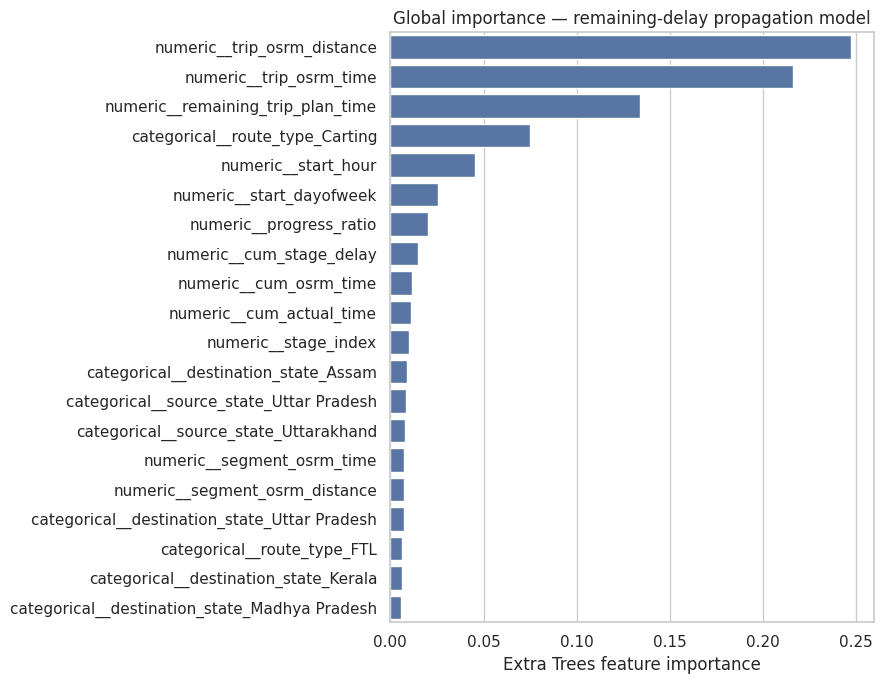

,feature,importance
0,numeric__trip_osrm_distance,0.247134
1,numeric__trip_osrm_time,0.215904
2,numeric__remaining_trip_plan_time,0.133705
3,categorical__route_type_Carting,0.074964
4,numeric__start_hour,0.045607
5,numeric__start_dayofweek,0.025573
6,numeric__progress_ratio,0.019993
7,numeric__cum_stage_delay,0.014826
8,numeric__cum_osrm_time,0.011755
9,numeric__cum_actual_time,0.011072


In [37]:
plt.figure(figsize=(9, 7))
sns.barplot(
    data=propagation_feature_importance_df,
    x='importance', y='feature', color='C0'
)
plt.title('Global importance — remaining-delay propagation model')
plt.xlabel('Extra Trees feature importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(propagation_feature_importance_df.style.set_caption(
    'Top factors explaining downstream/remaining delay'
))


def local_tree_shap_table(model, X_row, names, top_n=15):
    """Return a local SHAP table for a tree regressor with sparse-input support."""
    if not SHAP_AVAILABLE:
        return None
    X_dense = X_row.toarray() if sparse.issparse(X_row) else np.asarray(X_row)
    explainer = shap.TreeExplainer(model)
    values = explainer.shap_values(X_dense)
    if isinstance(values, list):
        values = values[-1]
    values = np.asarray(values)
    if values.ndim == 1:
        values = values.reshape(1, -1)
    if values.ndim != 2 or values.shape[1] != len(names):
        raise ValueError(f'Unexpected SHAP shape: {values.shape}')
    table = pd.DataFrame({
        'feature': np.asarray(names, dtype=str),
        'feature_value': X_dense[0],
        'shap_contribution': values[0],
    })
    table['abs_contribution'] = table['shap_contribution'].abs()
    return table.sort_values('abs_contribution', ascending=False).head(top_n)


In [38]:

eta_local_position = int(np.argmax(y_test_delay.to_numpy()))
eta_local_row = test_df.iloc[eta_local_position]
eta_local_summary = pd.Series({
    'trip_uuid': eta_local_row['trip_uuid'],
    'route': f"{eta_local_row['source_name']} → {eta_local_row['destination_name']}",
    'OSRM baseline minutes': eta_local_row['osrm_time'],
    'Predicted duration minutes': best_eta_pred[eta_local_position],
    'Predicted proxy delay minutes': delay_pred[eta_local_position],
    'Actual proxy delay minutes': eta_local_row['delay_minutes'],
})
print('Local ETA/delay example:')
display(eta_local_summary.to_frame('value'))


prop_rows_50 = checkpoint_predictions['50%']['rows']
prop_local_index = prop_rows_50['final_delay_minutes'].idxmax()
prop_local_row = stage_test.loc[prop_local_index]
prop_local_summary = pd.Series({
    'trip_uuid': prop_local_row['trip_uuid'],
    'selected progress': prop_local_row['progress_ratio'],
    'current stage delay': prop_local_row['current_stage_delay'],
    'cumulative stage delay': prop_local_row['cum_stage_delay'],
    'predicted remaining delay': predicted_remaining_delay_series.loc[prop_local_index],
    'predicted final delay': predicted_final_delay_series.loc[prop_local_index],
    'baseline final delay': baseline_final_delay_series.loc[prop_local_index],
    'actual final delay': prop_local_row['final_delay_minutes'],
})
print('Local propagation example:')
display(prop_local_summary.to_frame('value'))

if SHAP_AVAILABLE:
    eta_local_shap_df = local_tree_shap_table(
        final_eta_model, X_test_t[eta_local_position], feature_names
    )
    prop_local_shap_df = local_tree_shap_table(
        propagation_model, X_stage_test_t[prop_local_index], stage_feature_names
    )
    display(eta_local_shap_df.style.set_caption(
        'Local SHAP — factors changing predicted trip duration'
    ))
    display(prop_local_shap_df.style.set_caption(
        'Local SHAP — factors changing predicted remaining delay'
    ))
else:
    eta_local_shap_df = None
    prop_local_shap_df = None
    print('SHAP is unavailable in this environment; use the global feature-importance tables above.')


Local ETA/delay example:


,value
trip_uuid,trip-153843695443252828
route,Pappadahandi_Central_DPP_2 (Orissa) → Visakhapatnam_Gajuwaka_IP (Andhra Pradesh)
OSRM baseline minutes,211.000
Predicted duration minutes,804.650
Predicted proxy delay minutes,593.650
Actual proxy delay minutes,"7,687.552"


Local propagation example:


,value
trip_uuid,trip-153843695443252828
selected progress,1.000
current stage delay,"2,330.000"
cumulative stage delay,"2,330.000"
predicted remaining delay,465.601
predicted final delay,"2,795.601"
baseline final delay,"2,330.000"
actual final delay,"7,687.552"


,feature,feature_value,shap_contribution,abs_contribution
1,numeric__osrm_distance,0.232548,148.806539,148.806539
0,numeric__osrm_time,0.171836,119.044222,119.044222
9,categorical__route_type_FTL,0.000000,-29.945334,29.945334
2,numeric__start_hour,0.468379,29.788243,29.788243
8,categorical__route_type_Carting,1.000000,-17.476620,17.476620
6,numeric__planned_speed_kmph,1.290509,14.618182,14.618182
7,numeric__planned_minutes_per_km,-1.071977,12.618186,12.618186
129,categorical__state_corridor_Maharashtra → Maharashtra,0.000000,-6.642970,6.642970
53,categorical__destination_state_Maharashtra,0.000000,-5.121578,5.121578
63,categorical__destination_state_West Bengal,0.000000,-4.826950,4.826950


,feature,feature_value,shap_contribution,abs_contribution
12,numeric__trip_osrm_distance,-0.569192,140.146433,140.146433
9,numeric__remaining_trip_plan_time,-0.697919,-95.706224,95.706224
11,numeric__trip_osrm_time,-0.605360,66.329421,66.329421
8,numeric__progress_ratio,1.291943,-53.112054,53.112054
15,categorical__route_type_Carting,1.000000,-41.631416,41.631416
5,numeric__cum_actual_time,2.992046,33.521397,33.521397
2,numeric__segment_osrm_distance,14.826036,29.298244,29.298244
7,numeric__cum_stage_delay,7.008233,23.981290,23.981290
3,numeric__current_stage_delay,48.307057,22.126667,22.126667
0,numeric__segment_actual_time,47.425688,19.588112,19.588112


## 14. Single-Shipment Prediction Example


In [39]:
def predict_trip_at_start(row):
    """Predict duration, ETA, proxy delay, and severe-delay probability for one trip."""
    X_row = row[START_FEATURES].to_frame().T
    X_row_t = ensure_sparse(start_preprocessor.transform(X_row))

    predicted_duration = max(float(final_eta_model.predict(X_row_t)[0]), 0.0)
    predicted_delay = predicted_duration - float(row['osrm_time'])
    severe_probability = float(positive_class_probability(
        classifier, X_row_t
    )[0])
    predicted_eta = row['trip_start_time'] + pd.to_timedelta(
        predicted_duration, unit='m'
    )

    return pd.Series({
        'trip_uuid': row['trip_uuid'],
        'origin': row['source_name'],
        'destination': row['destination_name'],
        'selected ETA model': deployment_eta_model_name,
        'selected severe-delay classifier': best_classifier_name,
        'OSRM baseline minutes': row['osrm_time'],
        'Predicted full elapsed minutes': predicted_duration,
        'Predicted proxy delay minutes': predicted_delay,
        'Predicted ETA': predicted_eta,
        'Severe delay probability': severe_probability,
        'Classification probability threshold': best_classification_threshold,
        'Actual full elapsed minutes': row['trip_duration_minutes'],
        'Actual proxy delay minutes': row['delay_minutes'],
        'Actual ETA': row['actual_eta'],
    })

example_prediction = predict_trip_at_start(test_df.iloc[0])
display(example_prediction.to_frame('value'))


,value
trip_uuid,trip-153800653897073708
origin,Dhule_MIDCAvdn_I (Maharashtra)
destination,Chalisgaon_BhadgDPP_D (Maharashtra)
selected ETA model,Extra Trees Regressor
selected severe-delay classifier,Extra Trees Classifier
OSRM baseline minutes,41.000
Predicted full elapsed minutes,181.506
Predicted proxy delay minutes,140.506
Predicted ETA,2018-09-27 03:03:49.314425910
Severe delay probability,0.374


## 15. Model Export and Conclusion


In [40]:
SAVE_ARTIFACTS = True

if SAVE_ARTIFACTS:
    artifact_dir = Path('/kaggle/working/artifacts') if Path('/kaggle/working').exists() else Path('artifacts')
    artifact_dir.mkdir(exist_ok=True, parents=True)

    joblib.dump(start_preprocessor, artifact_dir / 'start_preprocessor.joblib')
    joblib.dump(final_eta_model, artifact_dir / 'eta_extra_trees.joblib')
    joblib.dump(classifier, artifact_dir / 'severe_delay_extra_trees.joblib')
    joblib.dump(stage_preprocessor, artifact_dir / 'stage_preprocessor.joblib')
    joblib.dump(propagation_model, artifact_dir / 'delay_propagation_remaining_delay_extra_trees.joblib')

    eta_validation_results_df.to_csv(
        artifact_dir / 'eta_validation_extra_trees.csv', index=False
    )
    eta_test_results_df.to_csv(
        artifact_dir / 'eta_final_test_extra_trees.csv', index=False
    )
    delay_results_df.to_csv(
        artifact_dir / 'delay_magnitude_final_test.csv', index=False
    )
    classifier_validation_results_df.to_csv(
        artifact_dir / 'severe_delay_validation_extra_trees.csv', index=False
    )
    classification_test_results_df.to_csv(
        artifact_dir / 'severe_delay_final_test_extra_trees.csv', index=False
    )
    checkpoint_results_df.to_csv(
        artifact_dir / 'delay_propagation_checkpoints_with_baseline.csv', index=False
    )
    eta_feature_importance_df.to_csv(
        artifact_dir / 'eta_feature_importance.csv', index=False
    )
    classifier_feature_importance_df.to_csv(
        artifact_dir / 'severe_delay_feature_importance.csv', index=False
    )
    propagation_feature_importance_df.to_csv(
        artifact_dir / 'propagation_feature_importance.csv', index=False
    )
    if eta_local_shap_df is not None:
        eta_local_shap_df.to_csv(artifact_dir / 'eta_local_shap.csv', index=False)
    if prop_local_shap_df is not None:
        prop_local_shap_df.to_csv(artifact_dir / 'propagation_local_shap.csv', index=False)

    metadata = {
        'notebook_version': 'delhivery-long',
        'ground_truth_duration': 'trip_end_time - trip_start_time',
        'delay_definition': 'trip_duration_minutes - osrm_time (proxy, not official SLA delay)',
        'delay_threshold_minutes': DELAY_THRESHOLD_MINUTES,
        'classification_probability_threshold': best_classification_threshold,
        'start_features': START_FEATURES,
        'stage_features': STAGE_FEATURES,
        'eta_model': deployment_eta_model_name,
        'eta_reference_baseline': 'osrm_time (no ML)',
        'matrix_format': 'sparse CSR',
        'classification_model': CLASSIFIER_MODEL_NAME,
        'propagation_model': propagation_model_name,
        'propagation_target': 'final_delay_minutes - cum_stage_delay',
        'propagation_baseline': 'cum_stage_delay',
        'checkpoint_order': 'od_start_time ascending, actual_time ascending within leg',
        'eda_scope': 'external training only',
        'shap_available': SHAP_AVAILABLE,
        'external_train_trips': int(len(train_df)),
        'final_test_trips': int(len(test_df)),
    }
    (artifact_dir / 'metadata.json').write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8'
    )
    print(f'Artifacts saved to: {artifact_dir.resolve()}')
else:
    print('SAVE_ARTIFACTS=False — set it to True to save models under /kaggle/working/artifacts.')


Đã lưu artifacts tại: /kaggle/working/artifacts


### Conclusion

- ETA prediction uses an **Extra Trees Regressor** and is benchmarked against the OSRM baseline.
- Delay magnitude preserves negative values for early arrivals; evaluation metrics do not clip delay at zero.
- Severe delay classification uses an **Extra Trees Classifier** and safely handles splits containing only one class.
- Checkpoints are ordered correctly by ascending `actual_time` within each leg.
- Delay propagation predicts **remaining delay**, avoids aggregating future checkpoints, and is compared with a cumulative-delay baseline.
- Target-focused EDA uses only the external training set; the final test set is excluded from feature selection and tuning.
- Explainability includes global feature importance and optional local SHAP analysis.
- All preprocessed matrices remain in **CSR sparse matrix** format.
- Delay is a **proxy relative to OSRM routing time**, not an official SLA delay.

A complete submission should also include a `README`, `requirements.txt`, and a two-to-three-page technical report. This notebook focuses on data processing, modeling, evaluation, and interpretation.
